# B2 — BLIP Fine-Tuned Vietnamese VQA (LoRA + Translate Pipeline)

---
## Cell 1 — Cài đặt thư viện

In [1]:
# Cài đặt các thư viện cần thiết
!pip install -q "torchao>=0.16.0"
!pip install -q "peft>=0.10.0" transformers accelerate pillow tqdm deep_translator --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [2]:
# Sửa lỗi xung đột Pillow cho Gradio
!pip install "pillow<12.0" -q
print("Đã hạ cấp Pillow để tương thích với Gradio.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 45.0 MB/s eta 0:00:00
Đã hạ cấp Pillow để tương thích với Gradio.


---
## Cell 1b — Giải nén dữ liệu

In [3]:
!unzip -q /content/data.zip -d /content/data
print("Đã giải nén 'data.zip' vào thư mục '/content/data'")

data/images/bánh_cuốn/:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/),
         continuing with "central" filename version
data/images/bánh_cuốn/000001.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000001.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000002.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000002.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000003.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000003.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000004.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000004.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000005.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000005.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000006.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/

---
## Cell 2a — Translator (VI ↔ EN)

In [4]:
import os
import json
import time
from pathlib import Path

from deep_translator import GoogleTranslator


class ViEnTranslator:
    """
    Wrapper GoogleTranslator (deep_translator) — miễn phí, không cần API key.
    Dùng cho cả tiền xử lý dataset lẫn inference.
    """
    def __init__(self):
        self.vi2en = GoogleTranslator(source="vi", target="en")
        self.en2vi = GoogleTranslator(source="en", target="vi")

    def to_english(self, text: str) -> str:
        try:
            return self.vi2en.translate(text) or text
        except Exception:
            return text  # fallback: giữ nguyên nếu lỗi mạng

    def to_vietnamese(self, text: str) -> str:
        try:
            return self.en2vi.translate(text) or text
        except Exception:
            return text


# Khởi tạo translator dùng chung toàn notebook
translator = ViEnTranslator()
print("ViEnTranslator sẵn sàng (GoogleTranslator — miễn phí).")

ViEnTranslator sẵn sàng (GoogleTranslator — miễn phí).


---
## Cell 2b — Dịch dataset VI→EN (lưu cache)

In [ ]:
TRAIN_JSON_RAW = "data/data/train.json"
VAL_JSON_RAW = "data/data/val.json"

TRAIN_JSON_EN  = "data/data/train_en.json"   # cache tiếng Anh
VAL_JSON_EN = "data/data/val_en.json"


def translate_dataset(json_path: str, output_path: str, trans: ViEnTranslator):
    """
    Dịch question + answer sang tiếng Anh, thêm field question_en / answer_en.
    Lưu kết quả vào output_path. Nếu file đã tồn tại → bỏ qua.
    """
    if os.path.exists(output_path):
        print(f"Cache đã tồn tại, bỏ qua: {output_path}")
        return

    with open(json_path, "r", encoding="utf-8") as f:
        samples = json.load(f)

    print(f"Đang dịch {len(samples)} mẫu từ '{json_path}'...")
    for i, s in enumerate(samples):
        s["question_en"] = trans.to_english(s["question"])
        s["answer_en"]   = trans.to_english(s["answer"])

        # Throttle nhẹ mỗi 100 mẫu để tránh bị Google tạm block
        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{len(samples)} đã dịch...")
            time.sleep(1.0)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(samples, f, ensure_ascii=False, indent=2)

    print(f"Đã lưu cache: {output_path} ({len(samples)} mẫu)")


translate_dataset(TRAIN_JSON_RAW, TRAIN_JSON_EN, translator)
translate_dataset(VAL_JSON_RAW,   VAL_JSON_EN,   translator)
print("\nDịch dataset hoàn tất!")

Đang dịch 2400 mẫu từ 'data/data/train.json'...
  100/2400 đã dịch...
  200/2400 đã dịch...
  300/2400 đã dịch...
  400/2400 đã dịch...
  500/2400 đã dịch...
  600/2400 đã dịch...
  700/2400 đã dịch...
  800/2400 đã dịch...
  900/2400 đã dịch...
  1000/2400 đã dịch...
  1100/2400 đã dịch...
  1200/2400 đã dịch...
  1300/2400 đã dịch...
  1400/2400 đã dịch...
  1500/2400 đã dịch...
  1600/2400 đã dịch...
  1700/2400 đã dịch...
  1800/2400 đã dịch...
  1900/2400 đã dịch...
  2000/2400 đã dịch...
  2100/2400 đã dịch...
  2200/2400 đã dịch...
  2300/2400 đã dịch...
  2400/2400 đã dịch...
💾 Đã lưu cache: data/data/train_en.json (2400 mẫu)
Đang dịch 300 mẫu từ 'data/data/val.json'...
  100/300 đã dịch...
  200/300 đã dịch...
  300/300 đã dịch...
💾 Đã lưu cache: data/data/val_en.json (300 mẫu)

Dịch dataset hoàn tất!


---
## Cell 3 — Import & Cấu hình toàn cục

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler

from PIL import Image

from transformers import BlipProcessor, BlipForQuestionAnswering, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model

# CẤU HÌNH — T4 GPU trên Colab

# Dataset paths (dùng bản đã dịch sang tiếng Anh)
TRAIN_JSON = TRAIN_JSON_EN
VAL_JSON = VAL_JSON_EN

# Model pretrained từ HuggingFace Hub
MODEL_NAME  = "Salesforce/blip-vqa-base"

# Lưu checkpoint vào Google Drive để không mất khi runtime reset
OUTPUT_DIR  = "/content/checkpoints/blip_vqa_vi_lora"

# Hyperparameters tối ưu cho T4 (15 GB VRAM)
EPOCHS = 30
BATCH_SIZE = 4       
GRAD_ACCUM_STEPS  = 4       
LR = 3e-4
WEIGHT_DECAY = 0.01
MAX_QUESTION_LEN = 64
MAX_ANSWER_LEN = 128
NUM_WORKERS = 2  

# LoRA config (chỉ áp dụng trên text encoder/decoder)
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.1

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    print("Không phát hiện GPU! Vào Runtime → Change runtime type → GPU (T4)")

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


## Cell 4 — Dataset

In [7]:
class VietnameseVQADataset(Dataset):
    """
    Dataset VQA cho BLIP — dùng câu hỏi và câu trả lời tiếng Anh (đã dịch từ VI).

    Mỗi mẫu gồm: ảnh (PIL), question_en (str), answer_en (str).
    Processor của BLIP sẽ:
      - Resize + normalize ảnh → pixel_values
      - Tokenize câu hỏi     → input_ids, attention_mask
    Tokenizer riêng sẽ encode câu trả lời → labels (dùng -100 cho padding).
    """

    def __init__(self, json_path, data_root, processor):
        with open(json_path, "r", encoding="utf-8") as f:
            self.samples = json.load(f)
        self.data_root = Path(data_root)
        self.processor = processor

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Chuẩn hóa path: dấu gạch chéo ngược (Windows) → /
        img_relative = sample["image_path"].replace("\\", "/")
        img_path = self.data_root / img_relative

        # Mở ảnh, chuyển sang RGB để tránh lỗi với ảnh RGBA / Grayscale
        image = Image.open(img_path).convert("RGB")

        # Dùng bản tiếng Anh đã dịch — BLIP được pretrain hoàn toàn bằng tiếng Anh
        question = sample.get("question_en", sample["question"])
        answer   = sample.get("answer_en",   sample["answer"])

        # Encode ảnh + câu hỏi bằng BLIP processor
        encoding = self.processor(
            images=image,
            text=question,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=MAX_QUESTION_LEN,
        )

        # Encode câu trả lời thành labels
        answer_encoding = self.processor.tokenizer(
            answer,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=MAX_ANSWER_LEN,
        )

        decoder_input_ids      = answer_encoding.input_ids.squeeze(0).clone()
        decoder_attention_mask = answer_encoding.attention_mask.squeeze(0).clone()

        # Thay padding token id bằng -100 để loss không tính trên padding
        labels = decoder_input_ids.clone()
        pad_id = self.processor.tokenizer.pad_token_id
        labels[labels == pad_id] = -100

        return {
            "pixel_values":           encoding.pixel_values.squeeze(0),
            "input_ids":              encoding.input_ids.squeeze(0),
            "attention_mask":         encoding.attention_mask.squeeze(0),
            "decoder_input_ids":      decoder_input_ids,
            "decoder_attention_mask": decoder_attention_mask,
            "labels":                 labels,
        }


def collate_fn(batch):
    """Stack các tensor trong batch thành một tensor duy nhất."""
    return {
        "pixel_values":           torch.stack([x["pixel_values"]           for x in batch]),
        "input_ids":              torch.stack([x["input_ids"]              for x in batch]),
        "attention_mask":         torch.stack([x["attention_mask"]         for x in batch]),
        "decoder_input_ids":      torch.stack([x["decoder_input_ids"]      for x in batch]),
        "decoder_attention_mask": torch.stack([x["decoder_attention_mask"] for x in batch]),
        "labels":                 torch.stack([x["labels"]                 for x in batch]),
    }


print("Dataset class định nghĩa xong.")

Dataset class định nghĩa xong.


---
## Cell 5 — Load Processor & Model, áp dụng LoRA

**Kiến trúc BLIP-VQA-Base:**
```
BlipForQuestionAnswering
├── vision_model (ViT-Base)       ← FROZEN hoàn toàn (không train)
├── text_encoder (BERT-encoder)   ← LoRA trên query/key/value/dense
└── text_decoder (BERT-decoder)   ← LoRA trên query/key/value/dense
```

In [ ]:

# Load BLIP processor và base model
print("Đang load processor và model từ HuggingFace Hub...")

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForQuestionAnswering.from_pretrained(MODEL_NAME)

print("Load xong.")

# FREEZE hoàn toàn Vision Encoder
# Vision encoder đã học tốt từ pretrain → không cần fine-tune
# Freeze giúp training ổn định và tiết kiệm VRAM đáng kể
for param in model.vision_model.parameters():
    param.requires_grad = False

frozen_vision_params = sum(p.numel() for p in model.vision_model.parameters())
print(f"Vision encoder FROZEN: {frozen_vision_params / 1e6:.1f}M tham số đóng băng")


# Cấu hình LoRA — chỉ trên text_encoder và text_decoder
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["query", "key", "value", "dense"],
    lora_dropout=LORA_DROPOUT,
    bias="none",
)

# Wrap model với LoRA
model = get_peft_model(model, lora_config)

# Đảm bảo vision_model vẫn frozen sau khi PEFT wrap
for name, param in model.named_parameters():
    if "vision_model" in name and "lora_" not in name:
        param.requires_grad = False

model = model.to(DEVICE)

# In tổng kết tham số
print("\nThống kê tham số")
model.print_trainable_parameters()

trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
total       = sum(p.numel() for p in model.parameters())
print(f"Trainable : {trainable / 1e6:.2f}M / {total / 1e6:.2f}M ({100*trainable/total:.2f}%)")

Đang load processor và model từ HuggingFace Hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Load xong.
✅ Vision encoder FROZEN: 86.1M tham số đóng băng

--- Thống kê tham số ---
trainable params: 7,692,288 || all params: 368,922,428 || trainable%: 2.0851
Trainable : 7.69M / 368.92M (2.09%)


---
## Cell 6 — Kiểm tra dữ liệu & tạo DataLoader

In [ ]:
# Tạo datasets (dùng file JSON tiếng Anh đã cache)
print("Đang khởi tạo datasets...")
train_dataset = VietnameseVQADataset(TRAIN_JSON, "data", processor)
val_dataset = VietnameseVQADataset(VAL_JSON,  "data", processor)

print(f"  Train: {len(train_dataset)} mẫu")
print(f"  Val  : {len(val_dataset)} mẫu")

# Thử load 1 mẫu để kiểm tra
sample_item = train_dataset[0]
print(f"\nKiểm tra mẫu đầu tiên:")
print(f"  pixel_values shape : {sample_item['pixel_values'].shape}")
print(f"  input_ids shape    : {sample_item['input_ids'].shape}")
print(f"  labels shape       : {sample_item['labels'].shape}")
print("Dataset OK!")

# Tạo DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"\nSố bước mỗi epoch (train) : {len(train_loader)}")
print(f"Batch hiệu quả            : {BATCH_SIZE} × {GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS}")

Đang khởi tạo datasets...
  Train: 2400 mẫu
  Val  : 300 mẫu

Kiểm tra mẫu đầu tiên:
  pixel_values shape : torch.Size([3, 384, 384])
  input_ids shape    : torch.Size([64])
  labels shape       : torch.Size([128])
Dataset OK!

Số bước mỗi epoch (train) : 600
Batch hiệu quả            : 4 × 4 = 16


---
## Cell 7 — Optimizer & Scheduler

In [10]:
# Chỉ tối ưu các tham số có requires_grad=True (LoRA params trên text modules)
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

# Tổng số bước update (sau gradient accumulation)
total_update_steps = EPOCHS * (len(train_loader) // GRAD_ACCUM_STEPS)
warmup_steps       = total_update_steps // 10   # 10% đầu là warmup

# Cosine schedule với warmup
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_update_steps,
)

print(f"Tổng số update steps: {total_update_steps}")
print(f"Warmup steps        : {warmup_steps}")
print(f"Optimizer           : AdamW, LR={LR}")

Tổng số update steps: 4500
Warmup steps        : 450
Optimizer           : AdamW, LR=0.0003


---
## Cell 8 — Hàm Training & Validation
Mixed precision FP16 + gradient accumulation.

In [11]:
import time

# GradScaler cho mixed precision FP16 (T4 hỗ trợ đầy đủ)
scaler = GradScaler()

def run_epoch_train(model, loader, optimizer, scheduler):
    """Chạy 1 epoch training với FP16 mixed precision, trả về average loss."""
    model.train()
    total_loss    = 0.0
    total_samples = 0
    optimizer.zero_grad()

    n_steps     = len(loader)
    print_every = max(1, n_steps // 20)
    t_start     = time.time()

    for step, batch in enumerate(loader):
        pixel_values           = batch["pixel_values"].to(DEVICE, non_blocking=True)
        input_ids              = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask         = batch["attention_mask"].to(DEVICE, non_blocking=True)
        decoder_input_ids      = batch["decoder_input_ids"].to(DEVICE, non_blocking=True)
        decoder_attention_mask = batch["decoder_attention_mask"].to(DEVICE, non_blocking=True)
        labels                 = batch["labels"].to(DEVICE, non_blocking=True)

        # FP16 autocast: T4 dùng Tensor Cores → tăng tốc ~2x so với FP32
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                decoder_input_ids=decoder_input_ids,
                decoder_attention_mask=decoder_attention_mask,
                labels=labels,
            )
            loss = outputs.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss    += outputs.loss.item() * len(labels)
        total_samples += len(labels)

        if (step + 1) % print_every == 0 or (step + 1) == n_steps:
            elapsed   = time.time() - t_start
            remaining = elapsed / (step + 1) * (n_steps - step - 1)
            pct       = (step + 1) / n_steps * 100
            avg_loss  = total_loss / total_samples
            vram_used = torch.cuda.memory_reserved() / 1e9
            print(
                f"  [Train] {step+1:4d}/{n_steps} ({pct:5.1f}%) | "
                f"loss={avg_loss:.4f} | VRAM={vram_used:.1f}GB | "
                f"elapsed={elapsed:.0f}s | remain≈{remaining:.0f}s",
                flush=True,
            )

    return total_loss / total_samples


def run_epoch_val(model, loader):
    """Chạy 1 epoch validation với FP16, trả về average loss."""
    model.eval()
    total_loss    = 0.0
    total_samples = 0

    n_steps = len(loader)
    t_start = time.time()

    with torch.no_grad():
        for step, batch in enumerate(loader):
            pixel_values           = batch["pixel_values"].to(DEVICE, non_blocking=True)
            input_ids              = batch["input_ids"].to(DEVICE, non_blocking=True)
            attention_mask         = batch["attention_mask"].to(DEVICE, non_blocking=True)
            decoder_input_ids      = batch["decoder_input_ids"].to(DEVICE, non_blocking=True)
            decoder_attention_mask = batch["decoder_attention_mask"].to(DEVICE, non_blocking=True)
            labels                 = batch["labels"].to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    decoder_input_ids=decoder_input_ids,
                    decoder_attention_mask=decoder_attention_mask,
                    labels=labels,
                )

            total_loss    += outputs.loss.item() * len(labels)
            total_samples += len(labels)

    elapsed  = time.time() - t_start
    avg_loss = total_loss / total_samples
    print(f"  [Val  ] {n_steps}/{n_steps} (100.0%) | loss={avg_loss:.4f} | elapsed={elapsed:.0f}s", flush=True)
    return avg_loss

## Cell 9 — Vòng lặp Training chính

In [ ]:
import math

history = {"train_loss": [], "val_loss": []}
best_val_loss = math.inf
best_epoch    = -1
start_epoch   = 1

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Auto-resume ──
state_path = os.path.join(OUTPUT_DIR, "training_state.pt")
if os.path.exists(state_path):
    print("Phát hiện checkpoint cũ — đang resume...")
    state = torch.load(state_path, map_location=DEVICE)
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    history       = state["history"]
    best_val_loss = state["best_val_loss"]
    best_epoch    = state["best_epoch"]
    start_epoch   = state["epoch"] + 1
    print(f"   Resume từ epoch {start_epoch} | best_val_loss={best_val_loss:.4f}")

# Repo HuggingFace để push model (đổi thành repo của bạn)
REPO_NAME = "lpv30/DL-CK"

print(f"{'='*60}")
print(f"Bắt đầu training — {EPOCHS} epoch(s)")
print(f"Output dir      : {OUTPUT_DIR}")
print(f"Repo HF         : {REPO_NAME}")
print(f"{'='*60}\n")

for epoch in range(start_epoch, EPOCHS + 1):
    print(f"\n{'─'*55}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'─'*55}")

    torch.cuda.empty_cache()

    train_loss = run_epoch_train(model, train_loader, optimizer, scheduler)
    val_loss   = run_epoch_val(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"\nEpoch {epoch:2d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"Saved best locally.")

        try:
            model.push_to_hub(REPO_NAME, commit_message=f"Best model at epoch {epoch} (val_loss={val_loss:.4f})")
            print(f"Pushed BEST model to Hugging Face Hub!")
        except Exception as e:
            print(f"Lỗi khi push lên HF (Kiểm tra login): {e}")

    torch.save(
        {
            "epoch":          epoch,
            "optimizer":      optimizer.state_dict(),
            "scheduler":      scheduler.state_dict(),
            "history":        history,
            "best_val_loss":  best_val_loss,
            "best_epoch":     best_epoch,
        },
        state_path,
    )

print(f"\n{'='*60}")
print(f"Training hoàn tất! Best val_loss = {best_val_loss:.4f} (epoch {best_epoch})")
print(f"{'='*60}")

🔄 Phát hiện checkpoint cũ — đang resume...
   Resume từ epoch 3 | best_val_loss=1.3393
Bắt đầu training — 30 epoch(s)
Output dir      : /content/checkpoints/blip_vqa_vi_lora
Repo HF         : lpv30/DL-CK


───────────────────────────────────────────────────────
Epoch 3/30
───────────────────────────────────────────────────────
  [Train]   30/600 (  5.0%) | loss=1.0443 | VRAM=3.3GB | elapsed=10s | remain≈191s
  [Train]   60/600 ( 10.0%) | loss=1.1008 | VRAM=3.3GB | elapsed=20s | remain≈178s
  [Train]   90/600 ( 15.0%) | loss=1.0450 | VRAM=3.3GB | elapsed=29s | remain≈167s
  [Train]  120/600 ( 20.0%) | loss=1.0544 | VRAM=3.3GB | elapsed=39s | remain≈155s
  [Train]  150/600 ( 25.0%) | loss=1.0758 | VRAM=3.3GB | elapsed=48s | remain≈144s
  [Train]  180/600 ( 30.0%) | loss=1.0806 | VRAM=3.3GB | elapsed=58s | remain≈135s
  [Train]  210/600 ( 35.0%) | loss=1.0798 | VRAM=3.3GB | elapsed=67s | remain≈125s
  [Train]  240/600 ( 40.0%) | loss=1.1010 | VRAM=3.3GB | elapsed=77s | remain≈116s
  [Trai

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   2%|1         |  557kB / 30.8MB            

  🚀 Pushed BEST model to Hugging Face Hub!

───────────────────────────────────────────────────────
Epoch 4/30
───────────────────────────────────────────────────────
  [Train]   30/600 (  5.0%) | loss=0.8271 | VRAM=3.3GB | elapsed=10s | remain≈194s
  [Train]   60/600 ( 10.0%) | loss=0.9014 | VRAM=3.3GB | elapsed=20s | remain≈180s
  [Train]   90/600 ( 15.0%) | loss=0.9096 | VRAM=3.3GB | elapsed=30s | remain≈169s
  [Train]  120/600 ( 20.0%) | loss=0.8850 | VRAM=3.3GB | elapsed=39s | remain≈156s
  [Train]  150/600 ( 25.0%) | loss=0.8604 | VRAM=3.3GB | elapsed=49s | remain≈146s
  [Train]  180/600 ( 30.0%) | loss=0.8861 | VRAM=3.3GB | elapsed=58s | remain≈136s
  [Train]  210/600 ( 35.0%) | loss=0.8797 | VRAM=3.3GB | elapsed=68s | remain≈126s
  [Train]  240/600 ( 40.0%) | loss=0.8866 | VRAM=3.3GB | elapsed=77s | remain≈116s
  [Train]  270/600 ( 45.0%) | loss=0.8789 | VRAM=3.3GB | elapsed=87s | remain≈106s
  [Train]  300/600 ( 50.0%) | loss=0.8679 | VRAM=3.3GB | elapsed=97s | remain≈97s
  [T

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   2%|1         |  556kB / 30.8MB            

  🚀 Pushed BEST model to Hugging Face Hub!

───────────────────────────────────────────────────────
Epoch 5/30
───────────────────────────────────────────────────────
  [Train]   30/600 (  5.0%) | loss=0.7319 | VRAM=3.3GB | elapsed=10s | remain≈193s
  [Train]   60/600 ( 10.0%) | loss=0.6632 | VRAM=3.3GB | elapsed=20s | remain≈179s
  [Train]   90/600 ( 15.0%) | loss=0.6568 | VRAM=3.3GB | elapsed=29s | remain≈166s
  [Train]  120/600 ( 20.0%) | loss=0.6531 | VRAM=3.3GB | elapsed=39s | remain≈155s
  [Train]  150/600 ( 25.0%) | loss=0.6701 | VRAM=3.3GB | elapsed=49s | remain≈146s
  [Train]  180/600 ( 30.0%) | loss=0.6615 | VRAM=3.3GB | elapsed=59s | remain≈137s
  [Train]  210/600 ( 35.0%) | loss=0.6757 | VRAM=3.3GB | elapsed=68s | remain≈127s
  [Train]  240/600 ( 40.0%) | loss=0.6842 | VRAM=3.3GB | elapsed=78s | remain≈116s
  [Train]  270/600 ( 45.0%) | loss=0.6711 | VRAM=3.3GB | elapsed=87s | remain≈106s
  [Train]  300/600 ( 50.0%) | loss=0.6783 | VRAM=3.3GB | elapsed=97s | remain≈97s
  [T

KeyboardInterrupt: 

---
## Cell 10 — Vẽ đồ thị Loss

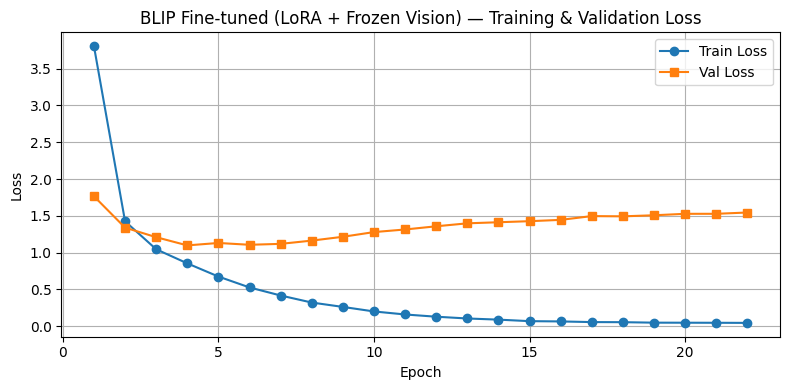

Đã lưu biểu đồ: loss_curve_B2.png


In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["val_loss"],   marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BLIP Fine-tuned (LoRA + Frozen Vision) — Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve_B2.png", dpi=150)
plt.show()
print("Đã lưu biểu đồ: loss_curve_B2.png")

---
## Cell 11 — Load checkpoint đã lưu (dùng khi mở lại notebook)
Chạy cell này nếu muốn load lại model đã fine-tune mà không train lại.

In [ ]:
from peft import PeftModel

print(f"Đang load checkpoint từ '{OUTPUT_DIR}'...")

base_model   = BlipForQuestionAnswering.from_pretrained(MODEL_NAME)
model_loaded = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
model_loaded = model_loaded.to(DEVICE)
model_loaded.eval()

processor_loaded = BlipProcessor.from_pretrained(OUTPUT_DIR)

# Khởi tạo lại translator nếu chưa có
try:
    translator
except NameError:
    from deep_translator import GoogleTranslator
    class ViEnTranslator:
        def __init__(self):
            self.vi2en = GoogleTranslator(source="vi", target="en")
            self.en2vi = GoogleTranslator(source="en", target="vi")
        def to_english(self, text):
            try: return self.vi2en.translate(text) or text
            except: return text
        def to_vietnamese(self, text):
            try: return self.en2vi.translate(text) or text
            except: return text
    translator = ViEnTranslator()

print("Load checkpoint thành công!")

## Cell 12 TEST: Dự đoán với ảnh & câu hỏi tiếng Việt

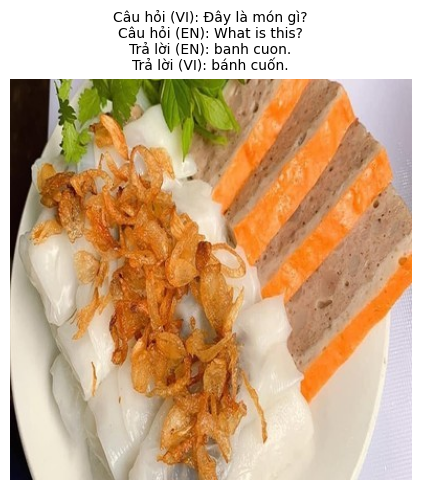


=== KẾT QUẢ ===
📷 Ảnh           : data/data/images/bánh_cuốn/000010.jpg
❓ Câu hỏi  (VI) : Đây là món gì?
❓ Câu hỏi  (EN) : What is this?
✅ Trả lời  (EN) : banh cuon.
✅ Trả lời  (VI) : bánh cuốn.


In [ ]:

TEST_IMAGE_PATH = "data/data/images/bánh_cuốn/000010.jpg"   # Đường dẫn ảnh muốn test
TEST_QUESTION   = "Đây là món gì?"                         # Câu hỏi tiếng Việt

# Hàm dự đoán (có pipeline dịch VI→EN→VI)
"""
Nhận ảnh và câu hỏi tiếng Việt, trả về câu trả lời tiếng Việt.
Pipeline:
  1. Dịch câu hỏi VI → EN  (GoogleTranslator)
  2. BLIP generate answer EN
  3. Dịch câu trả lời EN → VI  (GoogleTranslator)
    """
def predict_vi(image_path, question_vi, inference_model, inference_processor, trans, device):

    image = Image.open(image_path).convert("RGB")

    # Dịch câu hỏi sang tiếng Anh
    question_en = trans.to_english(question_vi)

    # BLIP inference bằng tiếng Anh
    inputs = inference_processor(
        images=image,
        text=question_en,
        return_tensors="pt",
    ).to(device)

    inference_model.eval()
    with torch.no_grad():
        output_ids = inference_model.generate(
            **inputs,
            max_new_tokens=50,
            num_beams=8,
            repetition_penalty=2.0,
            length_penalty=1.2,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )

    answer_en = inference_processor.decode(output_ids[0], skip_special_tokens=True)

    # Dịch câu trả lời sang tiếng Việt
    answer_vi = trans.to_vietnamese(answer_en)

    return {
        "question_vi": question_vi,
        "question_en": question_en,
        "answer_en":   answer_en,
        "answer_vi":   answer_vi,
        "image":       image,
    }


# Chạy dự đoán
try:
    _inf_model = model
    _inf_processor = processor
except NameError:
    _inf_model = model_loaded
    _inf_processor = processor_loaded

result = predict_vi(
    TEST_IMAGE_PATH,
    TEST_QUESTION,
    _inf_model,
    _inf_processor,
    translator,
    DEVICE,
)

# Hiển thị kết quả
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(result["image"])
ax.axis("off")
ax.set_title(
    f"Câu hỏi (VI): {result['question_vi']}\n"
    f"Câu hỏi (EN): {result['question_en']}\n"
    f"Trả lời (EN): {result['answer_en']}\n"
    f"Trả lời (VI): {result['answer_vi']}",
    fontsize=10
)
plt.tight_layout()
plt.show()

print("\nKẾT QUẢ")
print(f"Ảnh           : {TEST_IMAGE_PATH}")
print(f"Câu hỏi  (VI) : {result['question_vi']}")
print(f"Câu hỏi  (EN) : {result['question_en']}")
print(f"Trả lời  (EN) : {result['answer_en']}")
print(f"Trả lời  (VI) : {result['answer_vi']}")

---
## Cell 14 — Push Model lên Hugging Face Hub

In [13]:
from huggingface_hub import notebook_login

# Chạy cell này và dán Access Token (quyền WRITE) từ Hugging Face vào
notebook_login()

In [14]:
# Xác định model và processor cần đẩy lên
try:
    model_to_push     = model
    processor_to_push = processor
except NameError:
    model_to_push     = model_loaded
    processor_to_push = processor_loaded

print(f"Đang đẩy mô hình lên: {REPO_NAME}")
model_to_push.push_to_hub(REPO_NAME)
processor_to_push.push_to_hub(REPO_NAME)
print(f"Thành công! Xem mô hình tại: https://huggingface.co/{REPO_NAME}")

Đang đẩy mô hình lên: lpv30/DL-CK


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   2%|1         |  559kB / 30.8MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Thành công! Xem mô hình tại: https://huggingface.co/lpv30/DL-CK
